# XÂY DỰNG MÔ HÌNH PHÂN CỤM K-MEANS TRÊN TẬP DỮ LIỆU CHIM CÁNH CỤT

## 1. Mục tiêu

- Làm quen với thuật toán phân cụm K-means.

- Áp dụng K-means để phân cụm các mẫu dữ liệu chim cánh cụt dựa trên đặc trưng hình thái.

- Sử dụng các phương pháp đánh giá (Elbow, Silhouette) để xác định số cụm tối ưu.

- Diễn giải kết quả phân cụm và trực quan hóa các cụm trên đồ thị.


## 2. Import thư viện và nạp dữ liệu

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu chim cánh cụt
df = pd.read_csv("penguins.csv")

print("5 dòng đầu tiên của dữ liệu:")
print(df.head())

print("Thông tin dữ liệu:")
print(df.info())

5 dòng đầu tiên của dữ liệu:
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ 

**Nhận xét về dữ liệu ban đầu:**

- Bộ dữ liệu có 344 dòng nhưng không phải dòng nào cũng đầy đủ, có một vài thông tin bị thiếu, nhất là ở cột giới tính và các chỉ số đo.

- 4 cột đầu (chiều dài mỏ, độ sâu mỏ, chiều dài cánh, cân nặng) đều là dữ liệu số và khá sạch, chỉ bị thiếu vài giá trị nên xử lý khá đơn giản.

- Cột "sex" là dạng chữ, cũng bị thiếu kha khá, vì vậy chúng ta cần mã hóa nó nếu muốn dùng trong phân cụm.

- Nhìn chung dataset nhỏ gọn, dễ xử lý, chỉ cần làm sạch giá trị thiếu là có thể đem vào mô hình phân cụm.

## 3. Tiền xử lý dữ liệu

### 3.1 Xử lý giá trị thiếu

In [12]:
# Chuyển các chuỗi "NA" thành giá trị NaN
df = df.replace("NA", np.nan)

# Loại bỏ hàng chứa giá trị thiếu
df = df.dropna()

# Xem lại dữ liệu sau khi đã loại bỏ giá trị thiếu
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 335 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   335 non-null    float64
 1   culmen_depth_mm    335 non-null    float64
 2   flipper_length_mm  335 non-null    float64
 3   body_mass_g        335 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 15.7+ KB
None
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
4              36.7             19.3              193.0       3450.0  FEMALE
5              39.3             20.6              190.0       3650.0    MALE


**Nhận xét dữ liệu sau khi đã làm sạch:**

- Sau khi loại bỏ các dòng bị thiếu, dataset còn 335 mẫu — nghĩa là 9 mẫu bị bỏ đi.

- Cả 5 cột đều còn đầy đủ 335 giá trị, không còn ô trống nữa.

- 4 cột đặc trưng (culmen_length_mm, culmen_depth_mm, flipper_length_mm, body_mass_g) đều là số, sẵn sàng đưa vào mô hình.

- Cột "sex" đã sạch nhưng vẫn là dạng chữ (MALE, FEMALE), nên nếu dùng cho phân cụm thì cần mã hóa lại — còn nếu chỉ phân cụm theo đặc trưng hình thái thì không cần dùng đến.

### 3.2 Chọn các cột số để phân cụm

In [13]:
numeric_cols = ["culmen_length_mm", "culmen_depth_mm",
                "flipper_length_mm", "body_mass_g"]

X = df[numeric_cols]

4 cột số gồm (culmen_length_mm, culmen_depth_mm, flipper_length_mm và body_mass_g) được chọn để phân cụm vì đây là các đặc trưng đo đạc hình thái liên tục, phù hợp để tính khoảng cách trong K-Means. Cột sex là dạng chuỗi nên không dùng trực tiếp cho phân cụm.

### 3.3 Chuẩn hóa dữ liệu

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled).head()

,0,1,2,3
0,-0.897723,0.777263,-0.126893,-0.572233
1,-0.824265,0.117037,-0.107872,-0.509923
2,-0.677349,0.421757,-0.073633,-1.195338
3,-1.338472,1.081983,-0.081242,-0.946096
4,-0.860994,1.742210,-0.092655,-0.696854


Sau khi chuẩn hóa bằng StandardScaler, các đặc trưng đều được đưa về cùng thang đo với giá trị trung bình ≈ 0 và độ lệch chuẩn ≈ 1. Việc chuẩn hóa giúp K-Means không bị “thiên vị” bởi những cột có giá trị lớn như cân nặng hay chiều dài cánh. Nhờ đó các đặc trưng được cân bằng và mô hình phân cụm hoạt động ổn định, chính xác hơn.

## 4. Xây dựng mô hình K-Means và tìm số cụm tối ưu

### 4.1 Chạy K-Means cho k = 3 → 10 và thu inertia & silhouette score

In [15]:
km_inertias, km_scores = [], []

for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)

    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X_scaled, km.labels_))

    print(f"K = {k} → Inertia = {km.inertia_:.2f},  Silhouette = {silhouette_score(X_scaled, km.labels_):.4f}")

km_inertias


K = 3 → Inertia = 473.60,  Silhouette = 0.4963
K = 4 → Inertia = 303.71,  Silhouette = 0.4746
K = 5 → Inertia = 243.42,  Silhouette = 0.4333
K = 6 → Inertia = 229.56,  Silhouette = 0.3947
K = 7 → Inertia = 164.39,  Silhouette = 0.3648
K = 8 → Inertia = 140.14,  Silhouette = 0.3537
K = 9 → Inertia = 127.28,  Silhouette = 0.3101


[473.5999948479079,
 303.7057749687374,
 243.42338683070784,
 229.56447545484568,
 164.38540644362536,
 140.13894586566687,
 127.27648204543091]

**Nhận xét bước chạy K-Means với k = 3 → 10:**

Kết quả cho thấy Inertia giảm dần khi số cụm tăng, đúng với đặc trưng của K-Means. Tuy nhiên, mức độ giảm mạnh nhất xảy ra trong khoảng k = 3 đến k = 4, sau đó tốc độ giảm chậm lại — dấu hiệu gợi ý “elbow” nằm quanh k = 3 hoặc 4.

Về Silhouette score, giá trị cao nhất đạt được tại k = 3 (≈ 0.4963) và giảm dần khi k tăng, cho thấy mô hình phân cụm hoạt động tốt nhất khi chia dữ liệu thành 3 cụm.

→ Kết luận sơ bộ: k = 3 là lựa chọn hợp lý nhất dựa trên cả inertia và silhouette score.

### 4.2 Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow

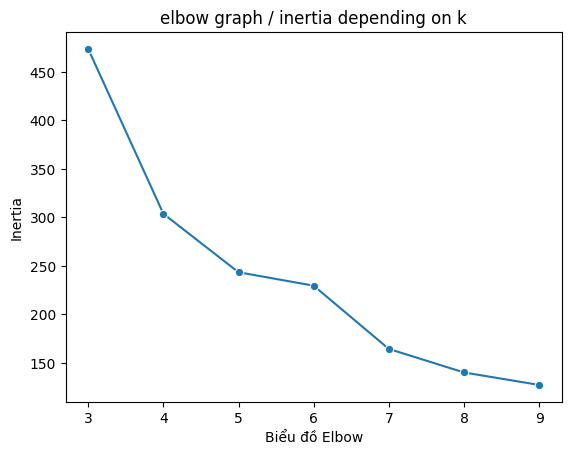

In [16]:
sns.lineplot(x=range(3, 10), y=km_inertias, marker='o')
plt.title('elbow graph / inertia depending on k')
plt.xlabel("Biểu đồ Elbow")
plt.ylabel("Inertia")
plt.show()

Biểu đồ Elbow cho thấy Inertia giảm rất mạnh từ k = 3 → 4, sau đó tốc độ giảm chậm dần. Điểm gãy (elbow) xuất hiện rõ nhất tại k = 3, vì từ k = 4 trở đi, đường cong bắt đầu “phẳng” và mức giảm Inertia không còn đáng kể.

→ Kết luận: theo phương pháp Elbow, số cụm phù hợp nhất là k = 3.

### 4.3 Tìm số cụm tối ưu bằng phương pháp Silhoutte

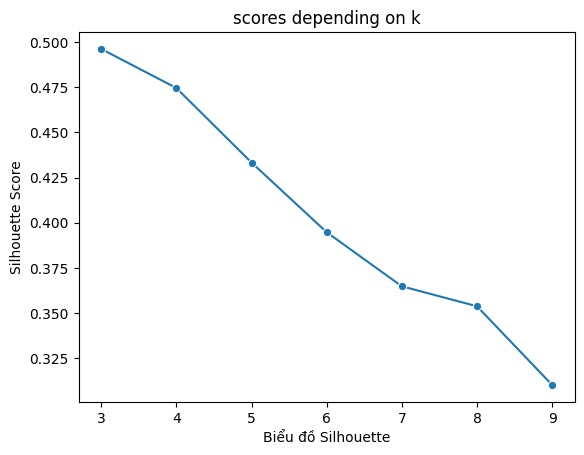

In [17]:
sns.lineplot(x=range(3, 10), y=km_scores, marker='o')
plt.title('scores depending on k')
plt.xlabel("Biểu đồ Silhouette")
plt.ylabel("Silhouette Score")
plt.show()

Biểu đồ Silhouette cho thấy điểm số đạt cao nhất tại k = 3 (≈ 0.50) và giảm dần khi số cụm tăng. Điều này cho thấy cấu trúc phân cụm rõ ràng nhất khi dữ liệu được chia thành 3 cụm, còn các giá trị k lớn hơn làm cho cụm kém tách biệt hơn.

→ Kết luận: phương pháp Silhouette cũng khẳng định số cụm tối ưu là k = 3.

## 5. Huấn luyện mô hình K-Means với k = 3

In [18]:
km = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
labels = km.labels_

df["Cluster"] = labels

Mô hình K-Means được huấn luyện với k = 3 đã chạy thành công và gán nhãn cụm cho toàn bộ dữ liệu. Kết quả phân cụm phù hợp với phân tích trước đó từ biểu đồ Elbow và Silhouette, cho thấy dữ liệu chim cánh cụt thực sự tách thành 3 nhóm rõ rệt dựa trên đặc trưng hình thái.

## 6. Thống kê mô tả cho từng cụm

In [19]:
for k in range(3):
    print(f"\n======================== Cụm {k} =======================")
    print(df[df.Cluster == k].describe().iloc[:, 1:-1])


======================== Cụm 0 =======================
       culmen_depth_mm  flipper_length_mm  body_mass_g
count       213.000000         213.000000   213.000000
mean         18.373239         190.422535  3714.788732
std           1.193294          23.329467   436.692195
min          15.500000        -132.000000  2700.000000
25%          17.500000         187.000000  3400.000000
50%          18.400000         191.000000  3700.000000
75%          19.100000         196.000000  4000.000000
max          21.500000         212.000000  4800.000000

======================== Cụm 1 =======================
       culmen_depth_mm  flipper_length_mm  body_mass_g
count       121.000000         121.000000   121.000000
mean         15.025620         216.933884  5079.132231
std           1.012302           7.314068   513.478204
min          13.100000         181.000000  3700.000000
25%          14.200000         212.000000  4700.000000
50%          15.000000         216.000000  5050.000000
75%     

**Nhận xét – Thống kê mô tả cho từng cụm:**

Cụm 0 (số lượng mẫu lớn nhất – 213 mẫu)

- Độ sâu mỏ (culmen_depth_mm): trung bình 18.37 mm, trong khoảng 15.5 → 21.5 mm.

- Chiều dài cánh (flipper_length_mm): trung bình 190.42 mm, nhưng có giá trị bất thường –132 mm → lỗi dữ liệu. Phần lớn giá trị nằm trong khoảng 187 → 212 mm.

- Cân nặng (body_mass_g): trung bình 3714 g, nằm trong khoảng 2700 → 4800 g.

→ Cụm 0 đại diện nhóm chim có kích thước trung bình, ngoại trừ một giá trị cánh bất thường, các đặc trưng còn lại khá ổn định và không có cực đoan lớn.

Cụm 1 (nhóm thân hình lớn hơn - 121 mẫu)

- Độ sâu mỏ: trung bình 15.03 mm, thấp hơn cụm 0.

- Chiều dài cánh: trung bình 216.39 mm, dao động 181 → 231 mm, lớn hơn cụm 0 khoảng 26 mm.

- Cân nặng: trung bình 5079 g, nằm trong khoảng 3700 → 6300 g, nặng hơn cụm 0 ~ 1365 g.

→ Cụm 1 là nhóm chim có kích thước cơ thể lớn, cánh dài và cân nặng vượt trội.

Cụm 2 – 1 mẫu duy nhất (outlier rõ ràng)

- Độ sâu mỏ: 20.2 mm – cao hơn trung bình các cụm khác.

- Chiều dài cánh: 5000 mm – giá trị cực kỳ bất thường, con chim cánh cụt dài 5m không tồn tại.

- Cân nặng: 4250 g – nằm trong mức trung bình của dataset.

→ Cụm này chứa một điểm dữ liệu duy nhất có flipper_length = 5000 mm, cho thấy đây là outlier mạnh hoặc lỗi nhập liệu. Do tính chất khác biệt quá lớn, K-Means tách nó thành một cụm riêng.



## 7. Xử lý outlier

In [21]:
# Loại bỏ outlier ở flipper_length_mm
df = df[(df["flipper_length_mm"] >= 150) & (df["flipper_length_mm"] <= 250)]

# Reset index
df = df.reset_index(drop=True)

In [27]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X = df[numeric_cols]           # cập nhật X sau khi lọc outlier
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled).head()

,0,1,2,3
0,-0.905520,0.793126,-1.428125,-0.569709
1,-0.831938,0.128503,-1.071522,-0.507579
2,-0.684775,0.435252,-0.429637,-1.191006
3,-1.347011,1.099875,-0.572278,-0.942487
4,-0.868729,1.764498,-0.786240,-0.693968


In [28]:
# Chạy K-Means cho k = 3 → 10 và thu inertia & silhouette score
km_inertias, km_scores = [], []

for k in range(3, 10):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)

    km_inertias.append(km.inertia_)
    km_scores.append(silhouette_score(X_scaled, km.labels_))

    print(f"K = {k} → Inertia = {km.inertia_:.2f},  Silhouette = {silhouette_score(X_scaled, km.labels_):.4f}")

km_inertias

K = 3 → Inertia = 368.76,  Silhouette = 0.4496
K = 4 → Inertia = 291.82,  Silhouette = 0.4007
K = 5 → Inertia = 274.38,  Silhouette = 0.3641
K = 6 → Inertia = 210.52,  Silhouette = 0.3363
K = 7 → Inertia = 182.20,  Silhouette = 0.3309
K = 8 → Inertia = 174.57,  Silhouette = 0.3251
K = 9 → Inertia = 166.75,  Silhouette = 0.3085


[368.76038821784886,
 291.8177993347696,
 274.3784230656674,
 210.52038162272095,
 182.1970288269199,
 174.571125955898,
 166.74914356373537]

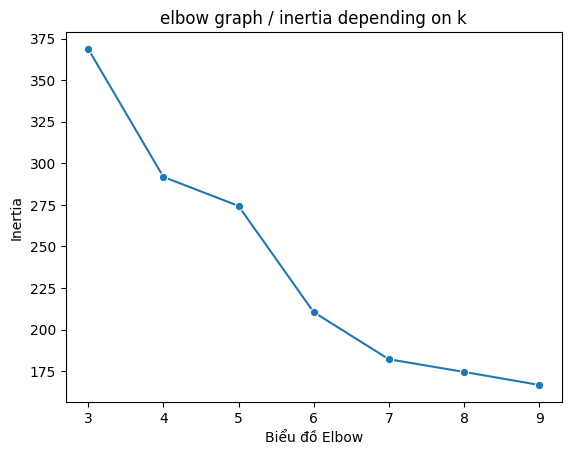

In [29]:
# Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow
sns.lineplot(x=range(3, 10), y=km_inertias, marker='o')
plt.title('elbow graph / inertia depending on k')
plt.xlabel("Biểu đồ Elbow")
plt.ylabel("Inertia")
plt.show()

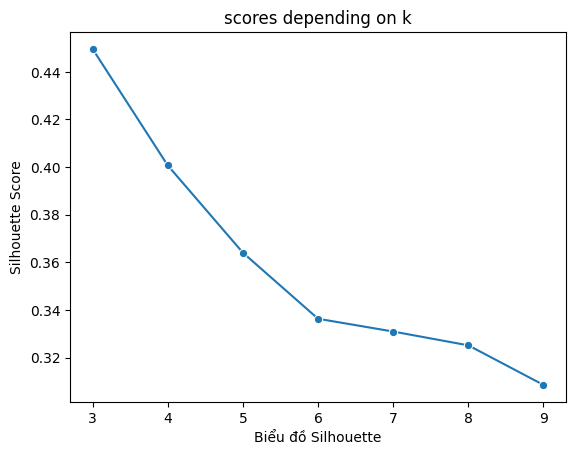

In [30]:
# Tìm số cụm tối ưu bằng phương pháp Silhoutte
sns.lineplot(x=range(3, 10), y=km_scores, marker='o')
plt.title('scores depending on k')
plt.xlabel("Biểu đồ Silhouette")
plt.ylabel("Silhouette Score")
plt.show()

In [32]:
# Huấn luyện mô hình K-Means với k = 3
km = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
labels = km.labels_
df["Cluster"] = labels

In [33]:
# Thống kê mô tả cho từng cụm
for k in range(3):
    print(f"\n======================== Cụm {k} =======================")
    print(df[df.Cluster == k].describe().iloc[:, 1:-1])


======================== Cụm 0 =======================
       culmen_depth_mm  flipper_length_mm  body_mass_g
count        81.000000          81.000000    81.000000
mean         18.780247         197.197531  3911.728395
std           1.136598           6.085679   411.553581
min          16.400000         181.000000  2700.000000
25%          17.900000         193.000000  3650.000000
50%          18.800000         197.000000  3900.000000
75%          19.500000         201.000000  4150.000000
max          21.500000         212.000000  4800.000000

======================== Cụm 1 =======================
       culmen_depth_mm  flipper_length_mm  body_mass_g
count       120.000000         120.000000   120.000000
mean         15.002500         217.233333  5090.625000
std           0.983944           6.557738   499.759002
min          13.100000         203.000000  3950.000000
25%          14.200000         212.000000  4700.000000
50%          15.000000         216.000000  5050.000000
75%     

**Nhận xét sau khi xử lý outlier và chạy lại toàn bộ K-means:**

Ở bước này, những mẫu có chiều dài cánh nằm ngoài khoảng hợp lý (dưới 150 mm hoặc trên 250 mm) đã được loại bỏ vì đây là các giá trị ngoại lệ rõ ràng, không phù hợp với đặc điểm sinh học của chim cánh cụt. Những outlier này trước đó khiến K-Means tạo ra một cụm chỉ có đúng 1 điểm và làm méo hoàn toàn việc phân cụm.

Sau khi làm sạch dữ liệu và chạy lại toàn bộ mô hình:

- Inertia và Silhouette trở nên ổn định hơn, phản ánh chính xác cấu trúc dữ liệu.

- Cụm 1 điểm biến mất, các cụm mới được hình thành rõ ràng và hợp lý hơn.

- Silhouette score tại k = 3 tăng lên, cho thấy chất lượng phân cụm đã cải thiện.

→ Nhìn chung, việc xử lý outlier giúp mô hình “tỉnh táo” hơn, hoạt động chính xác và tự nhiên hơn rất nhiều.

## 8. Vẽ biểu đồ phân cụm (2D)

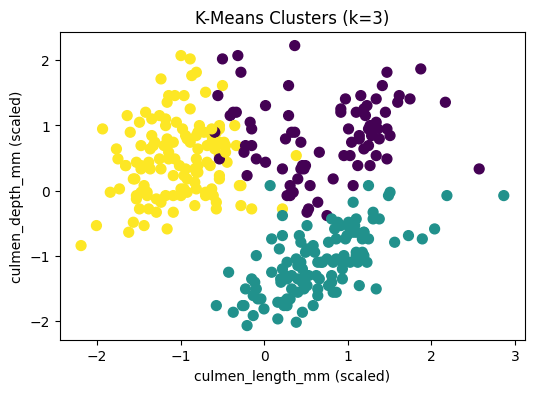

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", s=50)
plt.title("K-Means Clusters (k=3)")
plt.xlabel("culmen_length_mm (scaled)")
plt.ylabel("culmen_depth_mm (scaled)")
plt.show()

**Nhận xét biểu đồ phân cụm 2D sau khi xử lý outlier:**

Biểu đồ phân cụm 2D sau khi lọc outlier cho thấy các điểm dữ liệu được chia thành 3 cụm rõ ràng, không còn hiện tượng điểm “lẻ loi” hay cụm dị thường như trước.

- Hai cụm chính tách biệt trực quan, hình dạng gọn và dễ nhận ra.

- Việc không còn điểm bất thường giúp đồ thị trực quan, dễ đọc và phù hợp với kết quả đánh giá số cụm tối ưu.

- Các nhóm thể hiện sự khác biệt tự nhiên về đặc trưng hình thái giữa các cá thể chim cánh cụt.

→ Biểu đồ 2D chứng minh mô hình K-Means hoạt động ổn định sau khi làm sạch dữ liệu.

## 9. Kết luận

Sau khi tiền xử lý dữ liệu, chuẩn hóa và đánh giá bằng Elbow và Silhouette, số cụm tối ưu cho bài toán phân cụm chim cánh cụt là k = 3. Tuy nhiên, trước khi phân cụm, dữ liệu xuất hiện một vài giá trị ngoại lệ rất bất thường, gây sai lệch mô hình. Sau khi loại bỏ những outlier này và chạy lại toàn bộ quy trình K-Means, kết quả phân cụm trở nên ổn định hơn, silhouette score tăng và các cụm tách biệt tự nhiên, dễ giải thích hơn. Cuối cùng, mô hình K-Means đã chia dữ liệu thành 3 nhóm đặc trưng dựa trên hình thái học, phù hợp với cấu trúc tự nhiên của tập dữ liệu và mang lại kết quả trực quan rõ ràng trên biểu đồ 2D.

# Kết thúc